# 04 — Robust Model vs Baseline

This notebook provides the final comparison between the pretrained baseline AMC model and the adversarially trained robust AMC model.

The comparison uses the previously generated evaluation results from `results/`.

The analysis covers:

- Clean accuracy
- FGSM
- PGD
- MIM
- C&W
- Black-box transfer attack
- Attack Success Rate (ASR)
- Generalization gap across SNR
- C&W distortion metrics

**No models are retrained and no attacks are executed in this notebook.**

## Evaluation setup

- Dataset: RadioML2018.01A
- Number of modulation classes: 24
- SNR range: -20 dB to 30 dB
- FGSM epsilon: 0.02
- PGD epsilon: 0.02
- MIM epsilon: 0.02
- PGD/MIM steps: 10
- Black-box surrogate query budget: 5000

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RESULTS = ROOT / "results"

print("Project root:", ROOT)
print("Results directory:", RESULTS)
print("Results directory exists:", RESULTS.exists())

Project root: d:\MediCaps University\7 SEM\Project 1\AMCShield
Results directory: d:\MediCaps University\7 SEM\Project 1\AMCShield\results
Results directory exists: True


In [2]:
baseline_clean = pd.read_csv(RESULTS / "baseline_clean_results.csv")
baseline_fgsm = pd.read_csv(RESULTS / "baseline_fgsm_results.csv")
baseline_pgd = pd.read_csv(RESULTS / "baseline_pgd_results.csv")
baseline_mim = pd.read_csv(RESULTS / "baseline_mim_results.csv")
baseline_cw = pd.read_csv(RESULTS / "baseline_cw_results.csv")
baseline_blackbox = pd.read_csv(RESULTS / "baseline_blackbox_results.csv")

robust_clean = pd.read_csv(RESULTS / "clean_results.csv")
robust_fgsm = pd.read_csv(RESULTS / "fgsm_results.csv")
robust_pgd = pd.read_csv(RESULTS / "pgd_results.csv")
robust_mim = pd.read_csv(RESULTS / "mim_results.csv")
robust_cw = pd.read_csv(RESULTS / "cw_results.csv")
robust_blackbox = pd.read_csv(RESULTS / "blackbox_results.csv")

generalization_gap = pd.read_csv(RESULTS / "generalization_gap.csv")

print("All result files loaded successfully.")

All result files loaded successfully.


In [3]:
result_sets = {
    "Baseline Clean": baseline_clean,
    "Baseline FGSM": baseline_fgsm,
    "Baseline PGD": baseline_pgd,
    "Baseline MIM": baseline_mim,
    "Baseline C&W": baseline_cw,
    "Baseline Black-box": baseline_blackbox,
    "Robust Clean": robust_clean,
    "Robust FGSM": robust_fgsm,
    "Robust PGD": robust_pgd,
    "Robust MIM": robust_mim,
    "Robust C&W": robust_cw,
    "Robust Black-box": robust_blackbox,
}

for name, df in result_sets.items():
    print(
        f"{name:22s} | Rows: {len(df):2d} | "
        f"SNRs: {df['snr'].nunique():2d}"
    )

assert all(len(df) == 26 for df in result_sets.values())
assert all(df["snr"].nunique() == 26 for df in result_sets.values())

print("\nValidation passed: every evaluation result contains 26 SNR values.")

Baseline Clean         | Rows: 26 | SNRs: 26
Baseline FGSM          | Rows: 26 | SNRs: 26
Baseline PGD           | Rows: 26 | SNRs: 26
Baseline MIM           | Rows: 26 | SNRs: 26
Baseline C&W           | Rows: 26 | SNRs: 26
Baseline Black-box     | Rows: 26 | SNRs: 26
Robust Clean           | Rows: 26 | SNRs: 26
Robust FGSM            | Rows: 26 | SNRs: 26
Robust PGD             | Rows: 26 | SNRs: 26
Robust MIM             | Rows: 26 | SNRs: 26
Robust C&W             | Rows: 26 | SNRs: 26
Robust Black-box       | Rows: 26 | SNRs: 26

Validation passed: every evaluation result contains 26 SNR values.


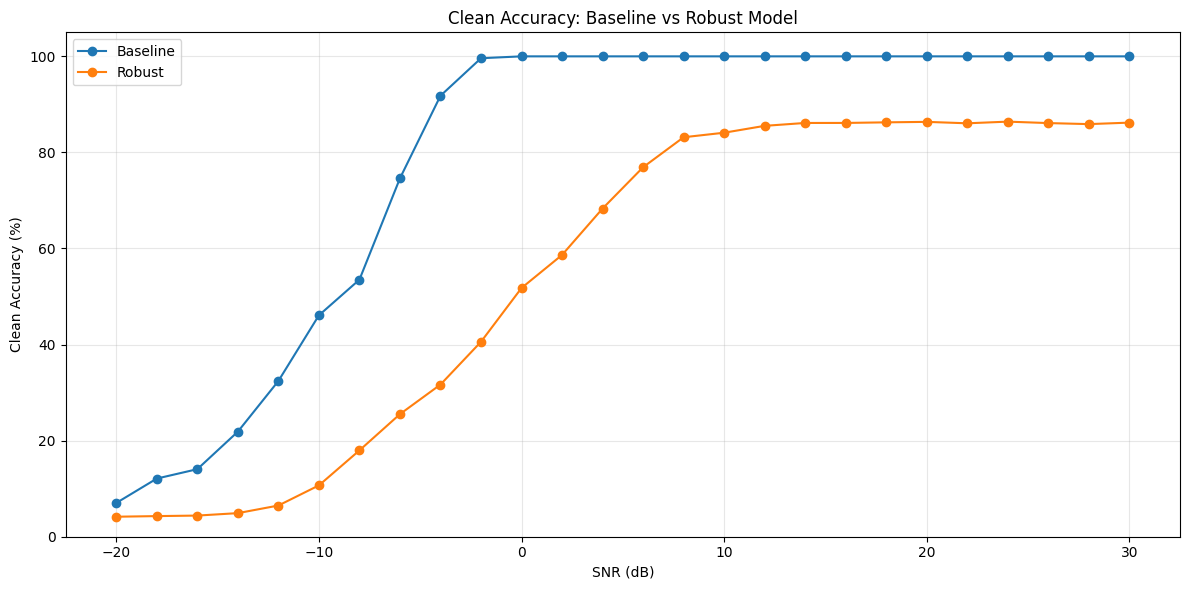

In [4]:
plt.figure(figsize=(12, 6))

plt.plot(
    baseline_clean["snr"],
    baseline_clean["clean_accuracy"],
    marker="o",
    label="Baseline"
)

plt.plot(
    robust_clean["snr"],
    robust_clean["accuracy"] * 100,
    marker="o",
    label="Robust"
)

plt.xlabel("SNR (dB)")
plt.ylabel("Clean Accuracy (%)")
plt.title("Clean Accuracy: Baseline vs Robust Model")
plt.ylim(0, 105)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

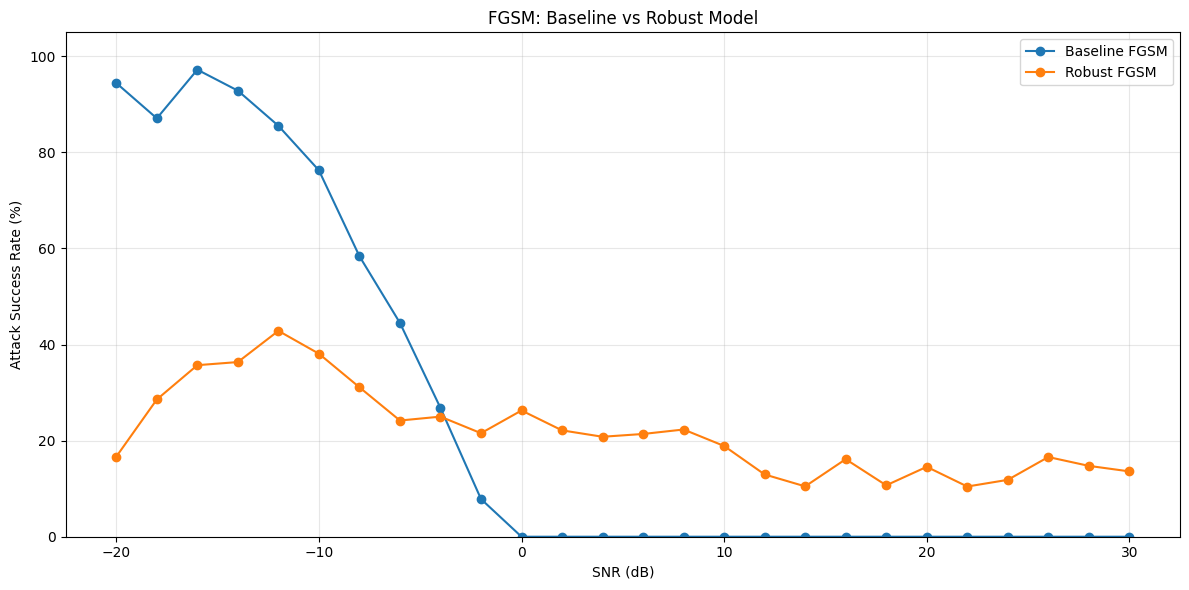

In [5]:
plt.figure(figsize=(12, 6))

plt.plot(
    baseline_fgsm["snr"],
    baseline_fgsm["attack_success_rate"],
    marker="o",
    label="Baseline FGSM"
)

plt.plot(
    robust_fgsm["snr"],
    robust_fgsm["attack_success_rate"] * 100,
    marker="o",
    label="Robust FGSM"
)

plt.xlabel("SNR (dB)")
plt.ylabel("Attack Success Rate (%)")
plt.title("FGSM: Baseline vs Robust Model")
plt.ylim(0, 105)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

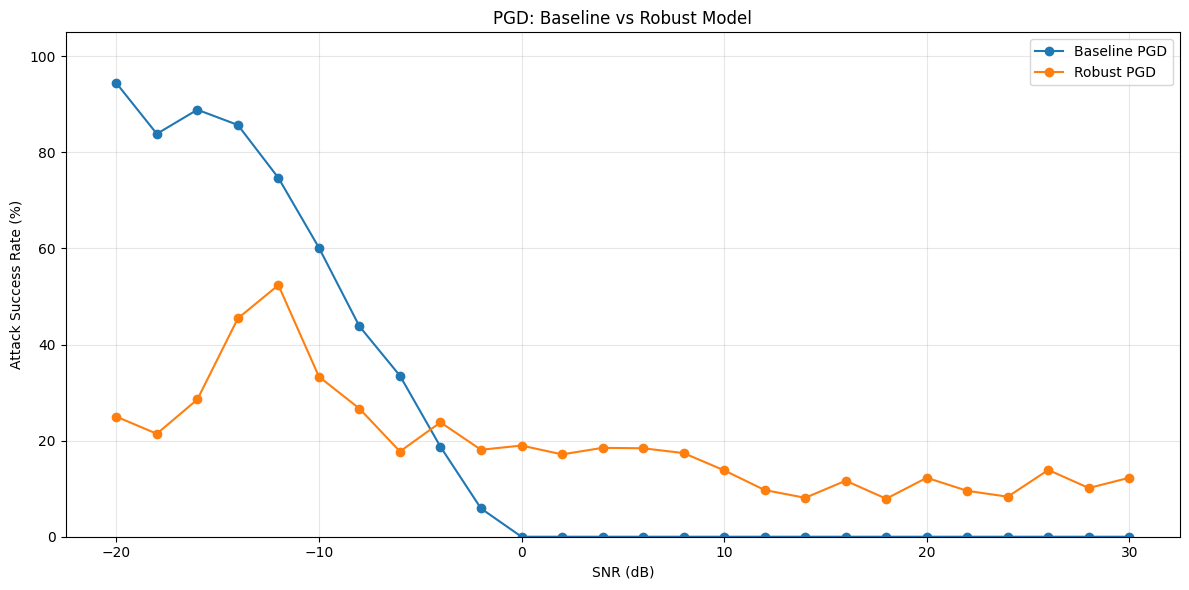

In [6]:
plt.figure(figsize=(12, 6))

plt.plot(
    baseline_pgd["snr"],
    baseline_pgd["attack_success_rate"],
    marker="o",
    label="Baseline PGD"
)

plt.plot(
    robust_pgd["snr"],
    robust_pgd["attack_success_rate"] * 100,
    marker="o",
    label="Robust PGD"
)

plt.xlabel("SNR (dB)")
plt.ylabel("Attack Success Rate (%)")
plt.title("PGD: Baseline vs Robust Model")
plt.ylim(0, 105)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

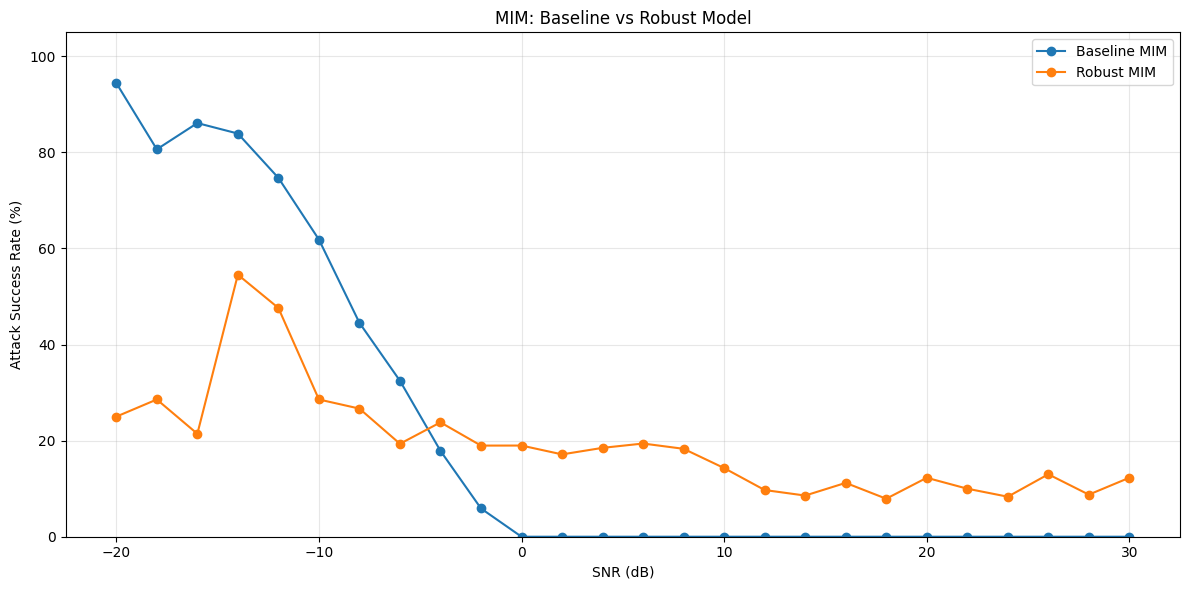

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(
    baseline_mim["snr"],
    baseline_mim["attack_success_rate"],
    marker="o",
    label="Baseline MIM"
)

plt.plot(
    robust_mim["snr"],
    robust_mim["attack_success_rate"] * 100,
    marker="o",
    label="Robust MIM"
)

plt.xlabel("SNR (dB)")
plt.ylabel("Attack Success Rate (%)")
plt.title("MIM: Baseline vs Robust Model")
plt.ylim(0, 105)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

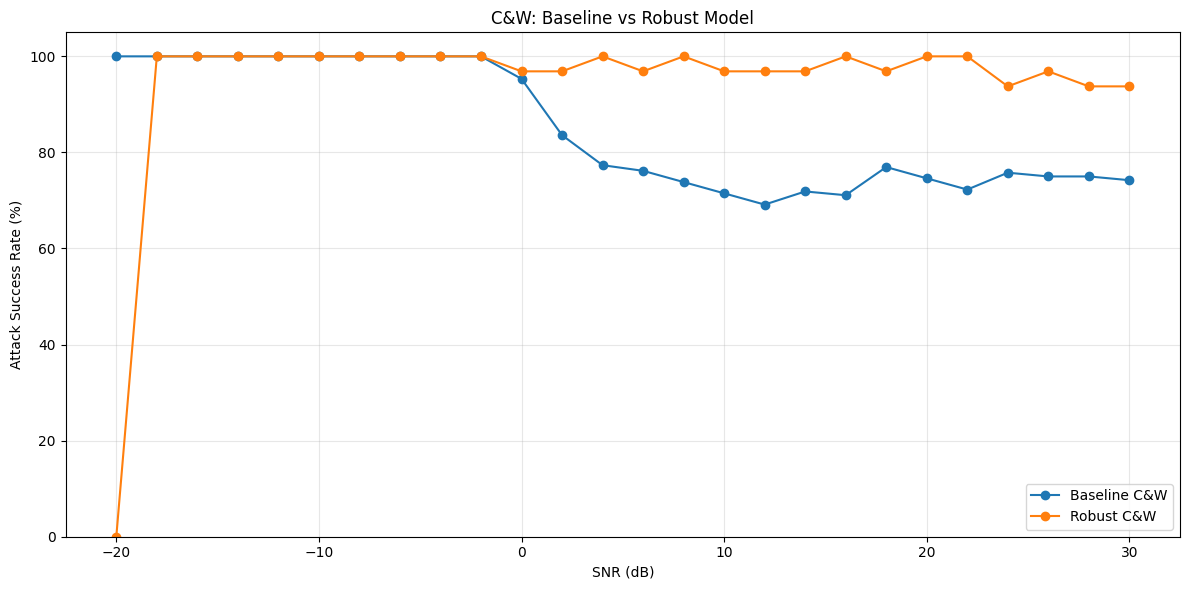

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(
    baseline_cw["snr"],
    baseline_cw["attack_success_rate"],
    marker="o",
    label="Baseline C&W"
)

plt.plot(
    robust_cw["snr"],
    robust_cw["attack_success_rate"] * 100,
    marker="o",
    label="Robust C&W"
)

plt.xlabel("SNR (dB)")
plt.ylabel("Attack Success Rate (%)")
plt.title("C&W: Baseline vs Robust Model")
plt.ylim(0, 105)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

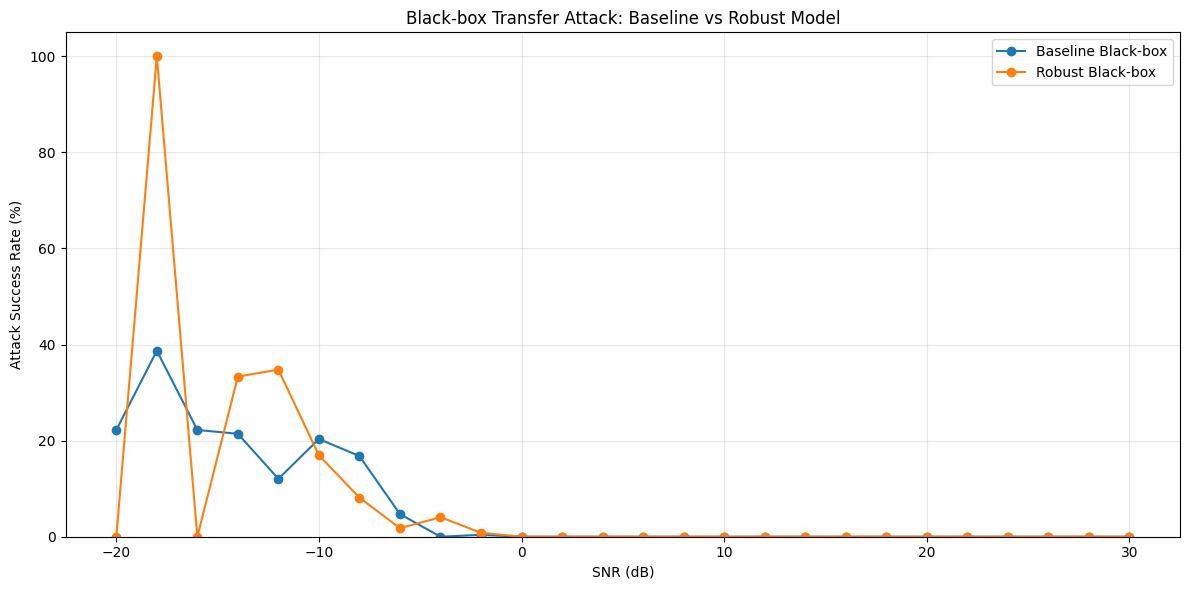

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(
    baseline_blackbox["snr"],
    baseline_blackbox["attack_success_rate"],
    marker="o",
    label="Baseline Black-box"
)

# Robust black-box ASR is already stored as a percentage.
plt.plot(
    robust_blackbox["snr"],
    robust_blackbox["attack_success_rate"],
    marker="o",
    label="Robust Black-box"
)

plt.xlabel("SNR (dB)")
plt.ylabel("Attack Success Rate (%)")
plt.title("Black-box Transfer Attack: Baseline vs Robust Model")
plt.ylim(0, 105)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

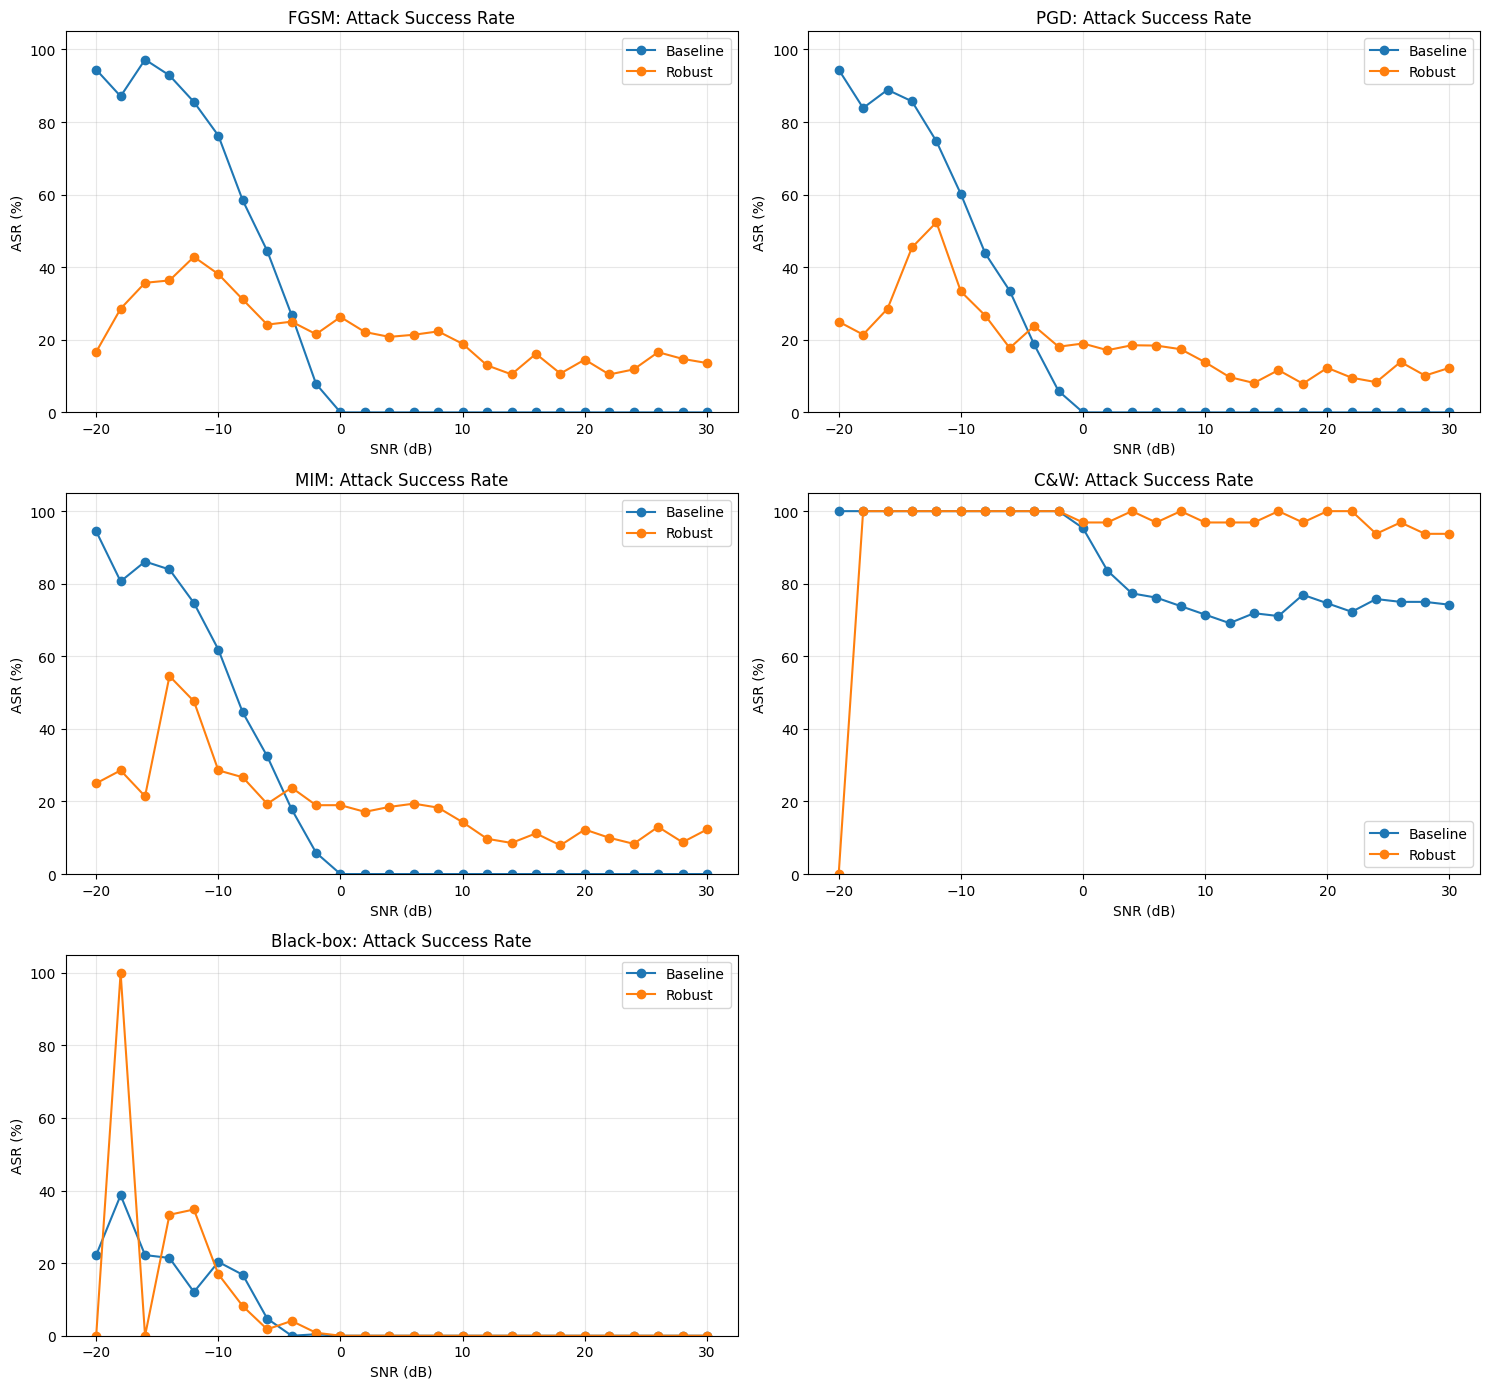

In [10]:
attacks = {
    "FGSM": (baseline_fgsm, robust_fgsm, True),
    "PGD": (baseline_pgd, robust_pgd, True),
    "MIM": (baseline_mim, robust_mim, True),
    "C&W": (baseline_cw, robust_cw, True),
    "Black-box": (baseline_blackbox, robust_blackbox, False),
}

fig, axes = plt.subplots(3, 2, figsize=(15, 14))
axes = axes.flatten()

for ax, (attack, (baseline, robust, robust_fraction)) in zip(axes, attacks.items()):
    ax.plot(
        baseline["snr"],
        baseline["attack_success_rate"],
        marker="o",
        label="Baseline"
    )

    robust_asr = robust["attack_success_rate"] * 100 if robust_fraction else robust["attack_success_rate"]

    ax.plot(
        robust["snr"],
        robust_asr,
        marker="o",
        label="Robust"
    )

    ax.set_title(f"{attack}: Attack Success Rate")
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("ASR (%)")
    ax.set_ylim(0, 105)
    ax.grid(alpha=0.3)
    ax.legend()

axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [11]:
display(generalization_gap.head())

,attack,snr,baseline_asr,robust_asr,gap
0,FGSM,-20,94.4444,0.1667,94.2777
1,FGSM,-18,87.0968,0.2857,86.8111
2,FGSM,-16,97.2222,0.3571,96.8651
3,FGSM,-14,92.8571,0.3636,92.4935
4,FGSM,-12,85.5422,0.4286,85.1136


In [12]:
display(
    generalization_gap[
        ["attack", "snr", "baseline_asr", "robust_asr", "gap"]
    ]
)

,attack,snr,baseline_asr,robust_asr,gap
0,FGSM,-20,94.4444,0.1667,94.2777
1,FGSM,-18,87.0968,0.2857,86.8111
2,FGSM,-16,97.2222,0.3571,96.8651
3,FGSM,-14,92.8571,0.3636,92.4935
4,FGSM,-12,85.5422,0.4286,85.1136
...,...,...,...,...,...
125,Black-box,22,0.0000,0.0000,0.0000
126,Black-box,24,0.0000,0.0000,0.0000
127,Black-box,26,0.0000,0.0000,0.0000
128,Black-box,28,0.0000,0.0000,0.0000


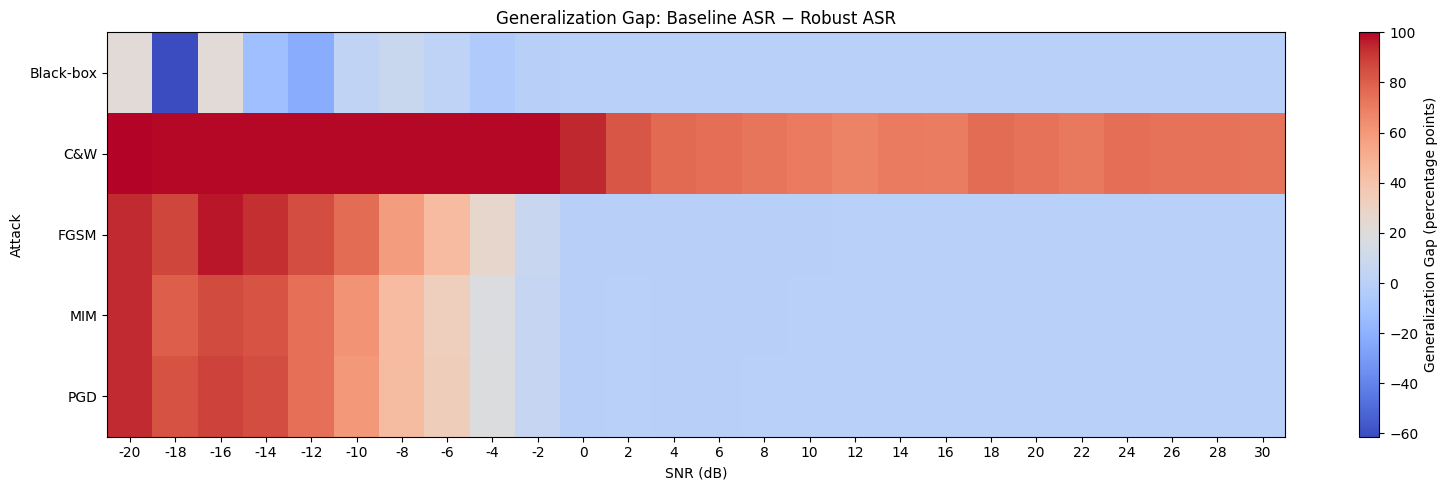

In [13]:
gap_pivot = generalization_gap.pivot(
    index="attack",
    columns="snr",
    values="gap"
)

plt.figure(figsize=(16, 5))

plt.imshow(
    gap_pivot.values,
    aspect="auto",
    cmap="coolwarm"
)

plt.colorbar(label="Generalization Gap (percentage points)")

plt.xticks(
    range(len(gap_pivot.columns)),
    gap_pivot.columns
)

plt.yticks(
    range(len(gap_pivot.index)),
    gap_pivot.index
)

plt.xlabel("SNR (dB)")
plt.ylabel("Attack")
plt.title("Generalization Gap: Baseline ASR − Robust ASR")
plt.tight_layout()
plt.show()

In [14]:
summary = []

attack_data = {
    "FGSM": (baseline_fgsm, robust_fgsm, True),
    "PGD": (baseline_pgd, robust_pgd, True),
    "MIM": (baseline_mim, robust_mim, True),
    "C&W": (baseline_cw, robust_cw, True),
    "Black-box": (baseline_blackbox, robust_blackbox, False),
}

for attack, (baseline, robust, robust_fraction) in attack_data.items():
    baseline_mean = baseline["attack_success_rate"].mean()
    robust_mean = robust["attack_success_rate"].mean()

    if robust_fraction:
        robust_mean *= 100

    summary.append({
        "Attack": attack,
        "Baseline Mean ASR (%)": baseline_mean,
        "Robust Mean ASR (%)": robust_mean,
        "Gap (percentage points)": baseline_mean - robust_mean,
    })

summary_df = pd.DataFrame(summary)
display(summary_df.round(2))

,Attack,Baseline Mean ASR (%),Robust Mean ASR (%),Gap (percentage points)
0,FGSM,25.81,21.69,4.11
1,PGD,22.68,19.25,3.43
2,MIM,22.40,19.35,3.05
3,C&W,85.14,94.47,-9.33
4,Black-box,6.11,7.69,-1.58


In [15]:
clean_summary = pd.DataFrame({
    "Model": ["Baseline", "Robust"],
    "Mean Clean Accuracy (%)": [
        baseline_clean["clean_accuracy"].mean(),
        robust_clean["accuracy"].mean() * 100,
    ],
})

display(clean_summary.round(2))

,Model,Mean Clean Accuracy (%)
0,Baseline,78.97
1,Robust,55.18


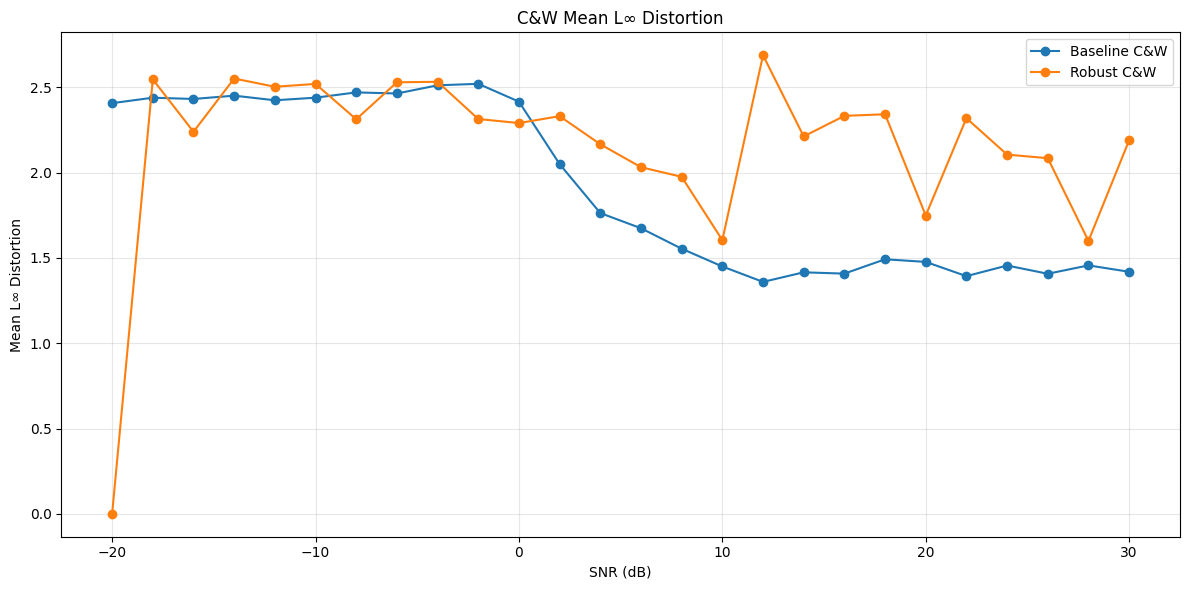

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(
    baseline_cw["snr"],
    baseline_cw["mean_linf"],
    marker="o",
    label="Baseline C&W"
)

plt.plot(
    robust_cw["snr"],
    robust_cw["mean_linf"],
    marker="o",
    label="Robust C&W"
)

plt.xlabel("SNR (dB)")
plt.ylabel("Mean L∞ Distortion")
plt.title("C&W Mean L∞ Distortion")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

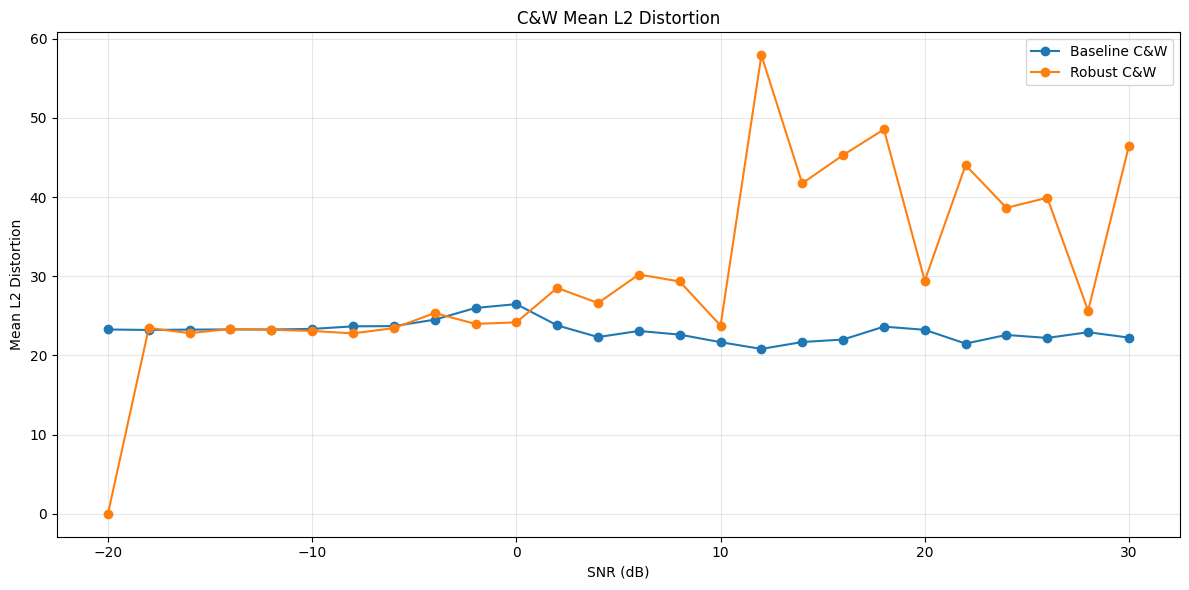

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(
    baseline_cw["snr"],
    baseline_cw["mean_l2"],
    marker="o",
    label="Baseline C&W"
)

plt.plot(
    robust_cw["snr"],
    robust_cw["mean_l2"],
    marker="o",
    label="Robust C&W"
)

plt.xlabel("SNR (dB)")
plt.ylabel("Mean L2 Distortion")
plt.title("C&W Mean L2 Distortion")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluation Notes

- FGSM, PGD and MIM use ε = 0.02.
- PGD and MIM use 10 attack steps.
- The black-box attack uses a surrogate model trained from 5,000 target-model queries.
- The black-box attack does not use target-model ground-truth labels during attack generation.
- C&W does not use the same ε = 0.02 L∞ projection as FGSM, PGD and MIM.
- Baseline attack evaluation uses 256 samples per SNR.
- Robust black-box evaluation uses 256 samples per SNR.
- The existing robust C&W result was evaluated on a smaller per-SNR subset and therefore should not be described as a 300-sample-per-SNR evaluation.
- Generalization gap is calculated as: **Baseline ASR − Robust ASR**, expressed in percentage points.
- Clean full-test accuracy and sampled attack-evaluation accuracy should be reported separately.
- In the result files used here, baseline ASR values are stored as percentages, while the robust FGSM/PGD/MIM/C&W ASR values are stored as fractions. Robust black-box ASR is already stored as a percentage. The plotting and summary cells normalize these representations explicitly.

## Conclusion

This notebook summarizes the previously generated AMCShield evaluation results without retraining either model or rerunning any attack.